In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

OUT = Path("overview_paper/manifold_panels")
OUT.mkdir(exist_ok=True)

DPI = 260
FIGSIZE = (3.0, 3.0)

WIRE = "0.62"
WIRE_LW = 0.55
PT_SIZE = 14

WRED = LinearSegmentedColormap.from_list(
    "wred", ["#ffffff", "#fee5d9", "#fcae91", "#fb6a4a", "#cb181d"]
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 10,
})

def norm01(x):
    x = np.asarray(x, dtype=float)
    x = x - np.nanmin(x)
    return x / (np.nanmax(x) + 1e-12)

def rgba_from_density(d, cmap=WRED, alpha_max=0.88, alpha_pow=1.15, cutoff=0.02):
    dn = norm01(d)
    rgba = cmap(dn)
    alpha = alpha_max * dn**alpha_pow
    alpha[dn < cutoff] = 0.0
    rgba[..., -1] = alpha
    return rgba

def angle_diff(a, b):
    return np.angle(np.exp(1j * (a - b)))

def ang_gauss_from_dot(dot, sigma):
    ang = np.arccos(np.clip(dot, -1.0, 1.0))
    return np.exp(-(ang**2) / (2 * sigma**2))

def set_equal_3d(ax, X, Y, Z, pad=0.01):
    xlim = np.array([np.min(X), np.max(X)])
    ylim = np.array([np.min(Y), np.max(Y)])
    zlim = np.array([np.min(Z), np.max(Z)])
    c = np.array([xlim.mean(), ylim.mean(), zlim.mean()])
    r = 0.5 * max(np.ptp(xlim), np.ptp(ylim), np.ptp(zlim)) * (1 + pad)
    ax.set_xlim(c[0] - r, c[0] + r)
    ax.set_ylim(c[1] - r, c[1] + r)
    ax.set_zlim(c[2] - r, c[2] + r)
    ax.set_box_aspect((1, 1, 1))

def style_3d(ax, elev=24, azim=-58):
    ax.set_axis_off()
    ax.view_init(elev=elev, azim=azim)

def new_3d_fig():
    fig = plt.figure(figsize=FIGSIZE)
    ax = fig.add_axes([0, 0, 1, 1], projection="3d")
    ax.set_position([-0.52, -0.52, 2.04, 2.04])  # much larger 3D object
    return fig, ax

def autocrop(path, pad=1, white_tol=247):
    img = Image.open(path).convert("RGBA")
    arr = np.array(img)
    rgb = arr[:, :, :3]
    alpha = arr[:, :, 3]
    # Matplotlib writes the white background as opaque, so alpha alone cannot
    # identify foreground. Treat near-white pixels as background instead.
    mask = (np.min(rgb, axis=2) < white_tol) & (alpha > 0)
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return
    x0 = max(xs.min() - pad, 0)
    x1 = min(xs.max() + pad + 1, arr.shape[1])
    y0 = max(ys.min() - pad, 0)
    y1 = min(ys.max() + pad + 1, arr.shape[0])
    Image.fromarray(arr[y0:y1, x0:x1]).save(path)

def manual_crop(path, frac=0.0):
    if frac <= 0:
        return
    img = Image.open(path).convert("RGBA")
    w, h = img.size
    dx = int(round(w * frac))
    dy = int(round(h * frac))
    if 2*dx >= w or 2*dy >= h:
        return
    img.crop((dx, dy, w - dx, h - dy)).save(path)

def save_panel(fig, path, pad=1, manual_crop_frac=0.0):
    fig.savefig(path, dpi=DPI, bbox_inches="tight", pad_inches=0.0)
    plt.close(fig)
    autocrop(path, pad=pad)
    manual_crop(path, frac=manual_crop_frac)

def orthonormal_basis_from_normal(n):
    n = np.asarray(n, dtype=float)
    n = n / np.linalg.norm(n)
    a = np.array([1.0, 0.0, 0.0]) if abs(n[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    e1 = np.cross(n, a)
    e1 = e1 / np.linalg.norm(e1)
    e2 = np.cross(n, e1)
    e2 = e2 / np.linalg.norm(e2)
    return e1, e2

In [6]:
def panel_s1(path=OUT / "01_s1.png"):
    fig, ax = plt.subplots(figsize=FIGSIZE)

    t = np.linspace(0, 2*np.pi, 480)
    x, y = np.cos(t), np.sin(t)

    mu = 0.85
    d = np.exp(4.2 * np.cos(t - mu))
    dn = norm01(d)

    c = WRED(dn)
    c[:, -1] = 0.82 * dn**1.25
    c[dn < 0.04, -1] = 0.0

    ax.plot(x, y, color=WIRE, lw=1.35, zorder=1)
    ax.scatter(x, y, c=c, s=18, zorder=2)
    ax.scatter([np.cos(mu)], [np.sin(mu)], c="k", s=PT_SIZE, zorder=3)

    ax.set_aspect("equal")
    ax.set_xlim(-1.32, 1.32)
    ax.set_ylim(-1.32, 1.32)
    ax.axis("off")

    # larger pad so the circle is not visually oversized after cropping
    save_panel(fig, path, pad=16)


def panel_s2(path=OUT / "02_s2.png"):
    fig, ax = new_3d_fig()

    u = np.linspace(0, 2*np.pi, 260)
    v = np.linspace(0, np.pi, 180)
    U, V = np.meshgrid(u, v)

    X = np.cos(U) * np.sin(V)
    Y = np.sin(U) * np.sin(V)
    Z = np.cos(V)

    mu = np.array([0.35, -0.45, 0.82])
    mu = mu / np.linalg.norm(mu)
    dot = X*mu[0] + Y*mu[1] + Z*mu[2]
    d = ang_gauss_from_dot(dot, sigma=0.38)  # mode/mean direction mu

    ax.plot_surface(X, Y, Z, facecolors=rgba_from_density(d), linewidth=0, shade=False, rstride=1, cstride=1)
    ax.plot_wireframe(X, Y, Z, rstride=11, cstride=11, color=WIRE, linewidth=WIRE_LW)
    ax.scatter(*mu, c="k", s=PT_SIZE, depthshade=False)

    style_3d(ax)
    set_equal_3d(ax, X, Y, Z)
    save_panel(fig, path)


def panel_t2(path=OUT / "03_t2.png"):
    fig, ax = new_3d_fig()

    u = np.linspace(0, 2*np.pi, 320)
    v = np.linspace(0, 2*np.pi, 240)
    U, V = np.meshgrid(u, v)

    R, r = 1.65, 0.55
    X = (R + r*np.cos(V)) * np.cos(U)
    Y = (R + r*np.cos(V)) * np.sin(U)
    Z = r * np.sin(V)

    u0, v0 = 2.15, 2.35
    su, sv = 0.46, 0.52
    d = np.exp(
        -(angle_diff(U, u0)**2)/(2*su**2)
        -(angle_diff(V, v0)**2)/(2*sv**2)
    )  # mode/mean at (u0,v0)

    x0 = (R + r*np.cos(v0)) * np.cos(u0)
    y0 = (R + r*np.cos(v0)) * np.sin(u0)
    z0 = r * np.sin(v0)

    ax.plot_surface(X, Y, Z, facecolors=rgba_from_density(d), linewidth=0, shade=False, rstride=1, cstride=1)
    ax.plot_wireframe(X, Y, Z, rstride=14, cstride=14, color=WIRE, linewidth=WIRE_LW)
    ax.scatter([x0], [y0], [z0], c="k", s=PT_SIZE, depthshade=False)

    style_3d(ax, elev=40, azim=-52)
    set_equal_3d(ax, X, Y, Z)
    save_panel(fig, path)


def panel_rp2(path=OUT / "04_rp2.png"):
    fig, ax = new_3d_fig()

    u = np.linspace(0, 2*np.pi, 260)
    v = np.linspace(0, np.pi, 180)
    U, V = np.meshgrid(u, v)

    X = np.cos(U) * np.sin(V)
    Y = np.sin(U) * np.sin(V)
    Z = np.cos(V)

    mu = np.array([0.72, 0.18, 0.67])
    mu = mu / np.linalg.norm(mu)
    dot = X*mu[0] + Y*mu[1] + Z*mu[2]

    d = ang_gauss_from_dot(dot, 0.30) + ang_gauss_from_dot(-dot, 0.30)

    ax.plot_surface(X, Y, Z, facecolors=rgba_from_density(d), linewidth=0, shade=False, rstride=1, cstride=1)
    ax.plot_wireframe(X, Y, Z, rstride=11, cstride=11, color=WIRE, linewidth=WIRE_LW)
    ax.plot([-mu[0], mu[0]], [-mu[1], mu[1]], [-mu[2], mu[2]], color="0.45", lw=0.85, alpha=0.75)
    ax.scatter([mu[0], -mu[0]], [mu[1], -mu[1]], [mu[2], -mu[2]], c="k", s=PT_SIZE-2, depthshade=False)

    style_3d(ax)
    set_equal_3d(ax, X, Y, Z)
    save_panel(fig, path)


def panel_grassmann(path=OUT / "05_grassmann.png"):
    fig, ax = new_3d_fig()

    u = np.linspace(0, 2*np.pi, 260)
    v = np.linspace(0, np.pi, 180)
    U, V = np.meshgrid(u, v)

    X = np.cos(U) * np.sin(V)
    Y = np.sin(U) * np.sin(V)
    Z = np.cos(V)

    # plane through origin; its normal determines the plane
    n = np.array([-0.34, 0.79, 0.51])
    n = n / np.linalg.norm(n)
    e1, e2 = orthonormal_basis_from_normal(n)

    # four modal representatives ±e1, ±e2 on the sphere
    d1 = X*e1[0] + Y*e1[1] + Z*e1[2]
    d2 = X*e2[0] + Y*e2[1] + Z*e2[2]
    d = (
        ang_gauss_from_dot(d1, 0.26) + ang_gauss_from_dot(-d1, 0.26) +
        ang_gauss_from_dot(d2, 0.26) + ang_gauss_from_dot(-d2, 0.26)
    )

    ax.plot_surface(X, Y, Z, facecolors=rgba_from_density(d, alpha_max=0.76), linewidth=0, shade=False, rstride=1, cstride=1)
    ax.plot_wireframe(X, Y, Z, rstride=11, cstride=11, color=WIRE, linewidth=WIRE_LW)

    # actual plane corresponding to the same two axes
    s = 1
    q = np.array([-s, s])
    Q1, Q2 = np.meshgrid(q, q)
    P = Q1[..., None] * e1 + Q2[..., None] * e2
    PX, PY, PZ = P[..., 0], P[..., 1], P[..., 2]

    plane_rgba = np.zeros(PX.shape + (4,))
    plane_rgba[..., 0] = 0.58
    plane_rgba[..., 1] = 0.02
    plane_rgba[..., 2] = 0.02
    plane_rgba[..., 3] = 0.25
    ax.plot_surface(PX, PY, PZ, facecolors=plane_rgba, linewidth=0, shade=False)

    corners = np.array([
        -s*e1 - s*e2,
         s*e1 - s*e2,
         s*e1 + s*e2,
        -s*e1 + s*e2,
        -s*e1 - s*e2,
    ])
    ax.plot(corners[:, 0], corners[:, 1], corners[:, 2], color="0.35", lw=0.85, alpha=0.95)

    for axis in (e1, e2):
        ax.plot(
            [-axis[0], axis[0]],
            [-axis[1], axis[1]],
            [-axis[2], axis[2]],
            color="0.45",
            lw=0.85,
            alpha=0.75,
        )

    # modes on the sphere cover
    modes = np.vstack([e1, -e1, e2, -e2])
    ax.scatter(modes[:, 0], modes[:, 1], modes[:, 2], c="k", s=PT_SIZE-3, depthshade=False)

    style_3d(ax)
    set_equal_3d(ax, X, Y, Z)
    save_panel(fig, path)


def lift_off_cone(a, b, c, eps=0.006):
    """
    Move points slightly off the PSD cone ac=b^2 to avoid z-fighting
    between the plotted surface and overlaid wire/guide curves.

    Cone implicit equation:
        F(a,b,c) = ac - b^2

    Normal direction:
        grad F = (c, -2b, a)
    """
    n = np.sqrt(c*c + 4*b*b + a*a)
    n = np.maximum(n, 1e-12)

    return (
        a + eps * c / n,
        b - eps * 2*b / n,
        c + eps * a / n,
    )


def panel_spd2(path=OUT / "06_spd2.png"):
    fig, ax = new_3d_fig()

    # Rank-1 PSD cone boundary:
    # [[a,b],[b,c]] = lambda * u u^T
    #
    # Use phi = 2 theta so the periodic coordinate is explicit:
    #   a = lambda cos^2(theta) = 0.5 lambda (1 + cos phi)
    #   b = lambda cos(theta) sin(theta) = 0.5 lambda sin phi
    #   c = lambda sin^2(theta) = 0.5 lambda (1 - cos phi)
    lam = np.linspace(0.06, 1.90, 200)
    phi = np.linspace(0, 2*np.pi, 260, endpoint=True)
    P, L = np.meshgrid(phi, lam, indexing="ij")

    A = 0.5 * L * (1 + np.cos(P))
    B = 0.5 * L * np.sin(P)
    C = 0.5 * L * (1 - np.cos(P))

    # Put the blob on a clearly visible side of the cone
    t0, l0 = 0.92, 1.18
    p0 = 2 * t0

    d = np.exp(
        -((0.5 * angle_diff(P, p0))**2) / (2 * 0.44**2)
        -((L - l0)**2) / (2 * 0.26**2)
    )

    # Mode point = center of this surrogate density
    a0 = 0.5 * l0 * (1 + np.cos(p0))
    b0 = 0.5 * l0 * np.sin(p0)
    c0 = 0.5 * l0 * (1 - np.cos(p0))

    # Surface: suppress all polygon edges explicitly.
    ax.plot_surface(
        A, B, C,
        facecolors=rgba_from_density(
            d,
            alpha_max=0.92,
            alpha_pow=1.0,
            cutoff=0.01,
        ),
        linewidth=0,
        edgecolor="none",
        shade=False,
        rstride=1,
        cstride=1,
        antialiased=False,
    )

    # Draw the wire manually, lifted slightly off the surface.
    # This avoids z-fighting with the transparent surface.
    wire_phi = np.linspace(0, 2*np.pi, 24, endpoint=False)

    for p in wire_phi:
        a = 0.5 * lam * (1 + np.cos(p))
        b = 0.5 * lam * np.sin(p)
        c = 0.5 * lam * (1 - np.cos(p))

        a, b, c = lift_off_cone(a, b, c, eps=0.006)
        ax.plot(a, b, c, color=WIRE, lw=WIRE_LW)

    ring_phi = np.linspace(0, 2*np.pi, 240, endpoint=True)

    for l in lam[::13]:
        a = 0.5 * l * (1 + np.cos(ring_phi))
        b = 0.5 * l * np.sin(ring_phi)
        c = 0.5 * l * (1 - np.cos(ring_phi))

        a, b, c = lift_off_cone(a, b, c, eps=0.006)
        ax.plot(a, b, c, color=WIRE, lw=WIRE_LW)

    # Mode point
    ax.scatter([a0], [b0], [c0], c="k", s=PT_SIZE, depthshade=False)

    # Faint guide curves, also lifted slightly off the surface.
    for t1 in [0.35, 0.9, 1.45]:
        p1 = 2 * t1
        l = np.linspace(0.0, 1.9, 140)

        a = 0.5 * l * (1 + np.cos(p1))
        b = 0.5 * l * np.sin(p1)
        c = 0.5 * l * (1 - np.cos(p1))

        a, b, c = lift_off_cone(a, b, c, eps=0.008)
        ax.plot(a, b, c, color="0.80", lw=0.70)

    style_3d(ax, elev=23, azim=-58)
    set_equal_3d(ax, A, B, C, pad=0.01)
    save_panel(fig, path, pad=1)


def render_all_panels():
    panel_s1()
    panel_s2()
    panel_t2()
    panel_rp2()
    panel_grassmann()
    panel_spd2()

render_all_panels()
sorted(OUT.glob("*.png"))

[PosixPath('overview_paper/manifold_panels/01_s1.png'),
 PosixPath('overview_paper/manifold_panels/02_s2.png'),
 PosixPath('overview_paper/manifold_panels/03_t2.png'),
 PosixPath('overview_paper/manifold_panels/04_rp2.png'),
 PosixPath('overview_paper/manifold_panels/05_grassmann.png'),
 PosixPath('overview_paper/manifold_panels/06_spd2.png')]

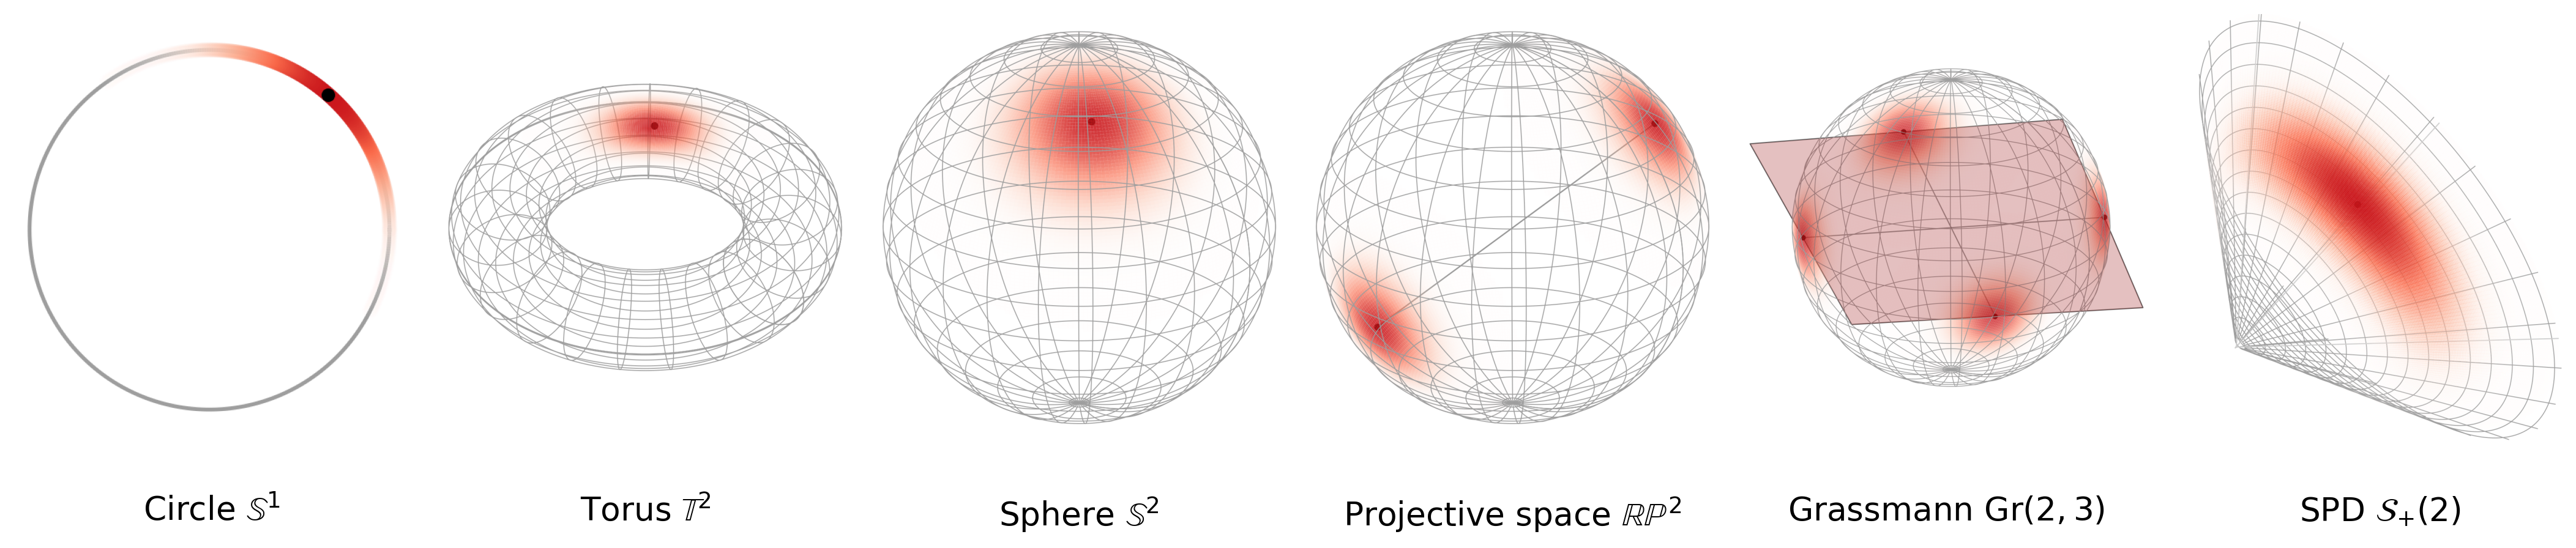

In [12]:
panel_files = [
    OUT / "01_s1.png",
    OUT / "03_t2.png",
    OUT / "02_s2.png",
    OUT / "04_rp2.png",
    OUT / "05_grassmann.png",
    OUT / "06_spd2.png",
]

labels = [
    r"Circle $\mathbb{S}^1$",
    r"Torus $\mathbb{T}^2$",
    r"Sphere $\mathbb{S}^2$",
    r"Projective space $\mathbb{RP}^2$",
    r"Grassmann $\mathrm{Gr}(2,3)$",
    r"SPD $\mathcal{S}_{+}(2)$",
]

fig, axes = plt.subplots(1, 6, figsize=(17.8, 3.5), dpi=240)

for ax, fp in zip(axes, panel_files):
    ax.imshow(Image.open(fp))
    ax.axis("off")

plt.subplots_adjust(wspace=0.1, left=0.01, right=0.99, top=0.99, bottom=0.16)
for ax, lab in zip(axes, labels):
    bbox = ax.get_position()
    fig.text((bbox.x0 + bbox.x1) / 2, 0.055, lab,
             ha="center", va="top", fontsize=16)
plt.show()
fig.savefig(OUT / "manifolds_1x6_pub2.png", dpi=260, bbox_inches="tight", pad_inches=0.02)